In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot
import tensorflow as tf
from keras import models
from keras import layers
from keras.layers import Dense, Conv2D, Flatten,MaxPooling2D,Dropout,ZeroPadding2D,BatchNormalization
from keras.optimizers import RMSprop,Adam
from keras.preprocessing.image import ImageDataGenerator
import random

In [4]:
# read train data from github
# Attention: click raw data and copy the link with raw data
# There are total 10 kinds, label: 0-9 

url = "https://raw.githubusercontent.com/HJNVR/Kaggle_Competitions/main/digit-recognizer/train.csv"
train = pd.read_csv(url)
#train.iloc[:,1:] = train.iloc[:,1:]/255.0 #normalization
print(train)

url = "https://raw.githubusercontent.com/HJNVR/Kaggle_Competitions/main/digit-recognizer/test.csv"
test = pd.read_csv(url)
#test.iloc[:,1:] = test.iloc[:,1:]/255.0 

       label  pixel0  pixel1  pixel2  ...  pixel780  pixel781  pixel782  pixel783
0          1       0       0       0  ...         0         0         0         0
1          0       0       0       0  ...         0         0         0         0
2          1       0       0       0  ...         0         0         0         0
3          4       0       0       0  ...         0         0         0         0
4          0       0       0       0  ...         0         0         0         0
...      ...     ...     ...     ...  ...       ...       ...       ...       ...
41995      0       0       0       0  ...         0         0         0         0
41996      1       0       0       0  ...         0         0         0         0
41997      7       0       0       0  ...         0         0         0         0
41998      6       0       0       0  ...         0         0         0         0
41999      9       0       0       0  ...         0         0         0         0

[42000 rows x 7

In [5]:
url = "https://raw.githubusercontent.com/HJNVR/Kaggle_Competitions/main/digit-recognizer/test.csv"
test = pd.read_csv(url)
#test.iloc[:,1:] = test.iloc[:,1:]/255.0
print(test)

       pixel0  pixel1  pixel2  pixel3  ...  pixel780  pixel781  pixel782  pixel783
0           0       0       0       0  ...         0         0         0         0
1           0       0       0       0  ...         0         0         0         0
2           0       0       0       0  ...         0         0         0         0
3           0       0       0       0  ...         0         0         0         0
4           0       0       0       0  ...         0         0         0         0
...       ...     ...     ...     ...  ...       ...       ...       ...       ...
27995       0       0       0       0  ...         0         0         0         0
27996       0       0       0       0  ...         0         0         0         0
27997       0       0       0       0  ...         0         0         0         0
27998       0       0       0       0  ...         0         0         0         0
27999       0       0       0       0  ...         0         0         0         0

[28

In [6]:
#Read the labels into a seprate array
y_train = train['label'].values
print(y_train)

# reshape train data
#convert the train images into a matrix of size 42,000 X 28 X 28 
train_images = train.loc[:,train.columns != 'label'].values
train_images = train_images.reshape(-1,28,28,1)
train_images.shape

[1 0 1 ... 7 6 9]


(42000, 28, 28, 1)

In [7]:
#convert the test images into a matrix of size 28,000 X 28 X 28 
test_images = test.values
test_images = test_images.reshape(-1,28,28,1)
test_images.shape

(28000, 28, 28, 1)

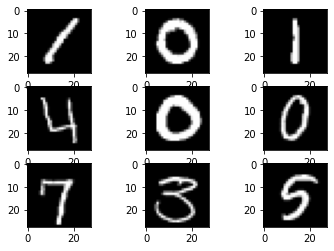

In [8]:
# create a grid of 3x3 images
for i in range(0, 9):
    pyplot.subplot(330 + 1 + i)
    pyplot.imshow(train_images[i].reshape(28,28), cmap=pyplot.get_cmap('gray'))
# show the plot
pyplot.show()

In [9]:
#Normalize

#reshape data to fit model

train_images = train_images/255.

test_images = test_images /255.



In [10]:

CNN_Model = tf.keras.models.Sequential([
    tf.keras.layers.ZeroPadding2D(padding=(1, 1), data_format=None,input_shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (5,5), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ZeroPadding2D(padding=(1, 1), data_format=None),
    tf.keras.layers.Conv2D(64, (6,6), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ZeroPadding2D(padding=(1, 1), data_format=None),
    tf.keras.layers.Conv2D(64, (7,7), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(5,5),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.45),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [11]:
from keras import optimizers

#network.compile(optimizer=RMSprop(lr=0.001),
CNN_Model.compile(optimizer=Adam(lr=0.001),
loss='categorical_crossentropy',
metrics=['accuracy'])

In [12]:
CNN_Model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
zero_padding2d (ZeroPadding2 (None, 30, 30, 1)         0         
_________________________________________________________________
conv2d (Conv2D)              (None, 26, 26, 32)        832       
_________________________________________________________________
batch_normalization (BatchNo (None, 26, 26, 32)        128       
_________________________________________________________________
zero_padding2d_1 (ZeroPaddin (None, 28, 28, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 23, 23, 64)        73792     
_________________________________________________________________
batch_normalization_1 (Batch (None, 23, 23, 64)        256       
_________________________________________________________________
zero_padding2d_2 (ZeroPaddin (None, 25, 25, 64)        0

In [13]:
from sklearn.model_selection  import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train_images, y_train, test_size=0.15)

In [14]:
from keras.utils import to_categorical
train_labels = to_categorical(y_train)
test_labels = to_categorical(y_test)
y_train = train_labels
y_train.shape

(35700, 10)

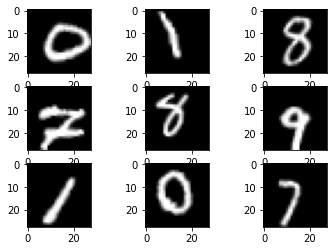

In [15]:
#datagen = ImageDataGenerator(featurewise_center=True, featurewise_std_normalization=True)
datagen = ImageDataGenerator( rotation_range=10,  
        zoom_range = 0.10,  
        width_shift_range=0.1, 
        height_shift_range=0.1)
# fit parameters from data
datagen.fit(X_train)

np.concatenate((X_train,X_train),axis=0)
random.seed(12345)
for X_batch, y_batch in datagen.flow(np.concatenate((X_train,X_train),axis=0), np.concatenate((y_train,y_train),axis=0), batch_size=35700):
  break
 
  
X_trainE = X_batch
y_trainE = y_batch


for i in range(0, 9):
        pyplot.subplot(330 + 1 + i)
        pyplot.imshow(X_trainE[i].reshape(28, 28), cmap=pyplot.get_cmap('gray'))
# show the plot
pyplot.show()



In [16]:


X_Combine = np.concatenate((X_train,X_trainE),axis=0)
y_combine = np.concatenate((y_train,y_trainE),axis=0)
print(X_Combine.shape)
print(y_combine.shape)



(71400, 28, 28, 1)
(71400, 10)


In [17]:
class myCallback(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs={}):
    if(logs.get('val_accuracy')>=0.9930): # use "val_accuracy" instead of "val_acc"
      print("\nReached 99.0% accuracy so cancelling training!")
      self.model.stop_training = True
      
callbacks = myCallback()

In [18]:
history = CNN_Model.fit(X_Combine, y_combine, epochs=60, batch_size=512,validation_data=(X_test,test_labels),callbacks=[callbacks])



Epoch 1/60
140/140 [==============================] - 1343s 10s/step - loss: 1.2825 - accuracy: 0.6692 - val_loss: 3.2893 - val_accuracy: 0.1024
Epoch 2/60
140/140 [==============================] - 1347s 10s/step - loss: 0.1772 - accuracy: 0.9466 - val_loss: 4.0787 - val_accuracy: 0.1024
Epoch 3/60
140/140 [==============================] - 1346s 10s/step - loss: 0.1155 - accuracy: 0.9652 - val_loss: 2.1913 - val_accuracy: 0.3848
Epoch 4/60
140/140 [==============================] - 1339s 10s/step - loss: 0.0742 - accuracy: 0.9775 - val_loss: 0.1107 - val_accuracy: 0.9625
Epoch 5/60
140/140 [==============================] - 1337s 10s/step - loss: 0.0671 - accuracy: 0.9802 - val_loss: 0.0325 - val_accuracy: 0.9902
Epoch 6/60
140/140 [==============================] - 1321s 9s/step - loss: 0.0516 - accuracy: 0.9836 - val_loss: 0.0257 - val_accuracy: 0.9937

Reached 99.0% accuracy so cancelling training!


In [19]:
test_loss, test_acc = CNN_Model.evaluate(X_test, test_labels)
print('test_acc:', test_acc)

197/197 [==============================] - 28s 142ms/step - loss: 0.0257 - accuracy: 0.9937
test_acc: 0.9936507940292358


In [22]:
#Make Prediction
predict = CNN_Model.predict(test_images)
#Convert the results to the digits value 
y_classes = [np.argmax(y, axis=None, out=None) for y in predict]

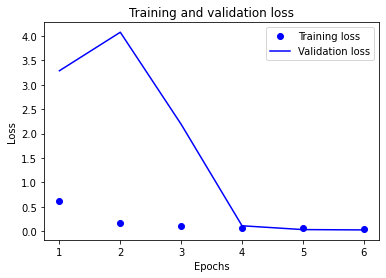

In [23]:


import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range (1,len(history_dict['loss'])+1)
#epochs = range(1, 36)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



In [24]:
x = list(range(1, 28001))
df = pd.DataFrame({'ImageId' :x,'Label':y_classes})
df.to_csv("output.csv",index=False)